In [1]:
import pandas as pd
import numpy as np

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/marketing_AB_clean.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 588,101
Columns: 6


In [2]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["most ads day"] = pd.Categorical(
    df["most ads day"],
    categories=day_order,
    ordered=True
)

print(df["most ads day"].cat.categories.tolist())

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


In [3]:
day_summary = (
    df.groupby(["most ads day", "test group"], observed=True)["converted"]
    .agg(
        users="count",
        conversions="sum"
    )
    .reset_index()
)

day_summary["conversion_rate"] = (
    day_summary["conversions"] / day_summary["users"]
)

day_summary["conversion_rate_pct"] = (
    day_summary["conversion_rate"] * 100
)

day_summary

,most ads day,test group,users,conversions,conversion_rate,conversion_rate_pct
0,Monday,ad,83571,2778,0.033241,3.324120
1,Monday,psa,3502,79,0.022559,2.255854
2,Tuesday,ad,74572,2270,0.030440,3.044038
3,Tuesday,psa,2907,42,0.014448,1.444788
4,Wednesday,ad,77418,1963,0.025356,2.535586
5,Wednesday,psa,3490,55,0.015759,1.575931
6,Thursday,ad,79077,1711,0.021637,2.163714
7,Thursday,psa,3905,79,0.020230,2.023047
8,Friday,ad,88805,1995,0.022465,2.246495
9,Friday,psa,3803,62,0.016303,1.630292


In [4]:
day_results = []

for day in day_order:
    day_data = df[df["most ads day"] == day]

    ad_data = day_data[day_data["test group"] == "ad"]
    psa_data = day_data[day_data["test group"] == "psa"]

    ad_users = len(ad_data)
    psa_users = len(psa_data)

    ad_conversions = ad_data["converted"].sum()
    psa_conversions = psa_data["converted"].sum()

    ad_rate_day = ad_conversions / ad_users
    psa_rate_day = psa_conversions / psa_users

    difference_day = ad_rate_day - psa_rate_day

    relative_lift_day = difference_day / psa_rate_day

    counts = np.array([ad_conversions, psa_conversions])
    sizes = np.array([ad_users, psa_users])

    z_day, p_day = proportions_ztest(
        count=counts,
        nobs=sizes,
        alternative="two-sided"
    )

    se_day = np.sqrt(
        (ad_rate_day * (1 - ad_rate_day) / ad_users)
        +
        (psa_rate_day * (1 - psa_rate_day) / psa_users)
    )

    ci_lower_day = difference_day - 1.96 * se_day
    ci_upper_day = difference_day + 1.96 * se_day

    cohens_h_day = (
        2 * np.arcsin(np.sqrt(ad_rate_day))
        - 2 * np.arcsin(np.sqrt(psa_rate_day))
    )

    day_results.append({
        "day": day,
        "ad_users": ad_users,
        "psa_users": psa_users,
        "ad_conversion_rate": ad_rate_day,
        "psa_conversion_rate": psa_rate_day,
        "absolute_difference": difference_day,
        "relative_lift": relative_lift_day,
        "z_statistic": z_day,
        "p_value": p_day,
        "ci_lower": ci_lower_day,
        "ci_upper": ci_upper_day,
        "cohens_h": cohens_h_day
    })

day_results = pd.DataFrame(day_results)

day_results

,day,ad_users,psa_users,ad_conversion_rate,psa_conversion_rate,absolute_difference,relative_lift,z_statistic,p_value,ci_lower,ci_upper,cohens_h
0,Monday,83571,3502,0.033241,0.022559,0.010683,0.473553,3.476598,5.078178e-04,0.005617,0.015749,0.065163
1,Tuesday,74572,2907,0.030440,0.014448,0.015992,1.106909,4.971771,6.634401e-07,0.011483,0.020502,0.109757
2,Wednesday,77418,3490,0.025356,0.015759,0.009597,0.608945,3.556091,3.764133e-04,0.005319,0.013874,0.068096
3,Thursday,79077,3905,0.021637,0.020230,0.001407,0.069532,0.590657,5.547506e-01,-0.003124,0.005937,0.009827
4,Friday,88805,3803,0.022465,0.016303,0.006162,0.377971,2.525029,1.156888e-02,0.002021,0.010303,0.044835
5,Saturday,78802,2858,0.021307,0.013996,0.007311,0.522354,2.674512,7.483818e-03,0.002887,0.011734,0.055819
6,Sunday,82332,3059,0.024620,0.020595,0.004025,0.195430,1.414599,1.571861e-01,-0.001118,0.009168,0.027103


In [5]:
# Benjamini–Hochberg correction for the 7 day-level tests

reject, p_adjusted, _, _ = multipletests(
    day_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

day_results["p_value_adjusted"] = p_adjusted
day_results["significant_after_bh"] = reject

day_results[
    [
        "day",
        "absolute_difference",
        "p_value",
        "p_value_adjusted",
        "significant_after_bh"
    ]
]

,day,absolute_difference,p_value,p_value_adjusted,significant_after_bh
0,Monday,0.010683,5.078178e-04,0.001185,True
1,Tuesday,0.015992,6.634401e-07,0.000005,True
2,Wednesday,0.009597,3.764133e-04,0.001185,True
3,Thursday,0.001407,5.547506e-01,0.554751,False
4,Friday,0.006162,1.156888e-02,0.016196,True
5,Saturday,0.007311,7.483818e-03,0.013097,True
6,Sunday,0.004025,1.571861e-01,0.183384,False


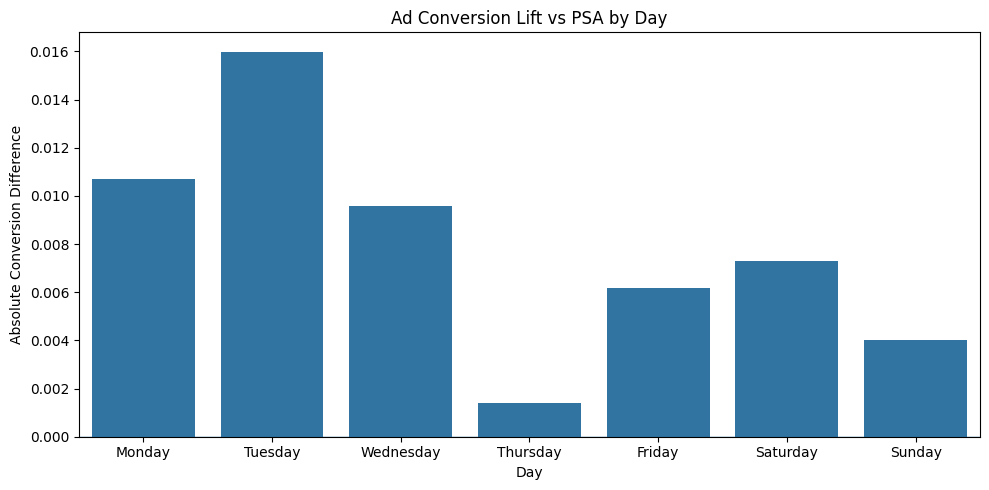

In [6]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=day_results,
    x="day",
    y="absolute_difference"
)

plt.axhline(0, linewidth=1)
plt.title("Ad Conversion Lift vs PSA by Day")
plt.xlabel("Day")
plt.ylabel("Absolute Conversion Difference")

plt.tight_layout()
plt.show()

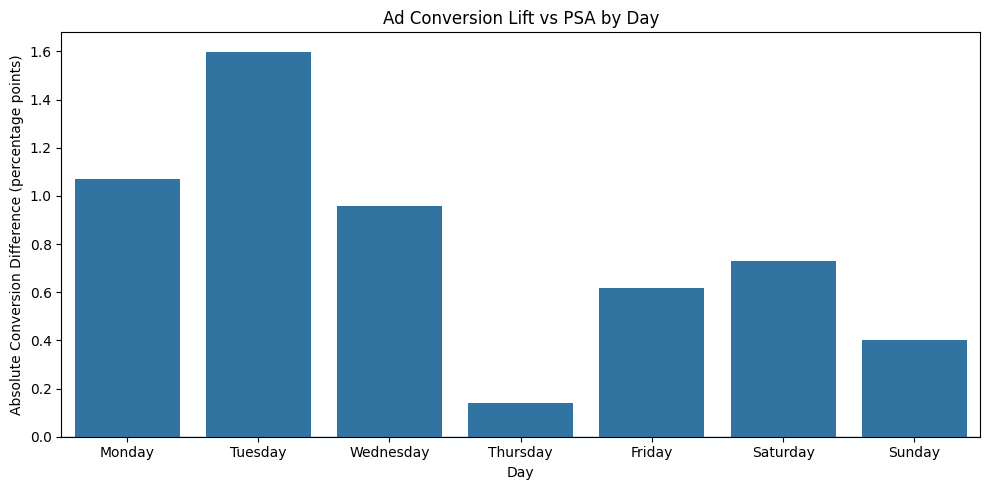

In [7]:
day_chart = day_results.copy()
day_chart["absolute_difference_pct"] = (
    day_chart["absolute_difference"] * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=day_chart,
    x="day",
    y="absolute_difference_pct"
)

plt.axhline(0, linewidth=1)
plt.title("Ad Conversion Lift vs PSA by Day")
plt.xlabel("Day")
plt.ylabel("Absolute Conversion Difference (percentage points)")

plt.tight_layout()
plt.show()

In [8]:
hour_summary = (
    df.groupby(["most ads hour", "test group"], observed=True)["converted"]
    .agg(
        users="count",
        conversions="sum"
    )
    .reset_index()
)

hour_summary["conversion_rate"] = (
    hour_summary["conversions"]
    / hour_summary["users"]
)

hour_summary["conversion_rate_pct"] = (
    hour_summary["conversion_rate"] * 100
)

hour_summary.head(10)

,most ads hour,test group,users,conversions,conversion_rate,conversion_rate_pct
0,0,ad,5309,102,0.019213,1.921266
1,0,psa,227,0,0.000000,0.000000
2,1,ad,4615,62,0.013434,1.343445
3,1,psa,187,0,0.000000,0.000000
4,2,ad,5152,39,0.007570,0.756988
5,2,psa,181,0,0.000000,0.000000
6,3,ad,2590,27,0.010425,1.042471
7,3,psa,89,1,0.011236,1.123596
8,4,ad,694,11,0.015850,1.585014
9,4,psa,28,0,0.000000,0.000000


In [9]:
hour_results = []

for hour in range(24):
    hour_data = df[df["most ads hour"] == hour]

    ad_data = hour_data[hour_data["test group"] == "ad"]
    psa_data = hour_data[hour_data["test group"] == "psa"]

    ad_users = len(ad_data)
    psa_users = len(psa_data)

    ad_conversions = ad_data["converted"].sum()
    psa_conversions = psa_data["converted"].sum()

    ad_rate_hour = ad_conversions / ad_users
    psa_rate_hour = psa_conversions / psa_users

    difference_hour = ad_rate_hour - psa_rate_hour

    relative_lift_hour = (
        difference_hour / psa_rate_hour
        if psa_rate_hour > 0
        else np.nan
    )

    counts = np.array([ad_conversions, psa_conversions])
    sizes = np.array([ad_users, psa_users])

    z_hour, p_hour = proportions_ztest(
        count=counts,
        nobs=sizes,
        alternative="two-sided"
    )

    se_hour = np.sqrt(
        (ad_rate_hour * (1 - ad_rate_hour) / ad_users)
        +
        (psa_rate_hour * (1 - psa_rate_hour) / psa_users)
    )

    ci_lower_hour = difference_hour - 1.96 * se_hour
    ci_upper_hour = difference_hour + 1.96 * se_hour

    cohens_h_hour = (
        2 * np.arcsin(np.sqrt(ad_rate_hour))
        - 2 * np.arcsin(np.sqrt(psa_rate_hour))
    )

    hour_results.append({
        "hour": hour,
        "ad_users": ad_users,
        "psa_users": psa_users,
        "ad_conversions": ad_conversions,
        "psa_conversions": psa_conversions,
        "ad_conversion_rate": ad_rate_hour,
        "psa_conversion_rate": psa_rate_hour,
        "absolute_difference": difference_hour,
        "relative_lift": relative_lift_hour,
        "z_statistic": z_hour,
        "p_value": p_hour,
        "ci_lower": ci_lower_hour,
        "ci_upper": ci_upper_hour,
        "cohens_h": cohens_h_hour
    })

hour_results = pd.DataFrame(hour_results)

hour_results

,hour,ad_users,psa_users,ad_conversions,psa_conversions,ad_conversion_rate,psa_conversion_rate,absolute_difference,relative_lift,z_statistic,p_value,ci_lower,ci_upper,cohens_h
0,0,5309,227,102,0,0.019213,0.000000,0.019213,NaN,2.107875,0.035042,0.015520,0.022905,0.278115
1,1,4615,187,62,0,0.013434,0.000000,0.013434,NaN,1.595338,0.110637,0.010113,0.016756,0.232336
2,2,5152,181,39,0,0.007570,0.000000,0.007570,NaN,1.174837,0.240060,0.005203,0.009937,0.174230
3,3,2590,89,27,1,0.010425,0.011236,-0.000811,-0.072201,-0.073994,0.941015,-0.023056,0.021434,-0.007839
4,4,694,28,11,0,0.015850,0.000000,0.015850,NaN,0.671320,0.502017,0.006558,0.025142,0.252465
5,5,742,23,16,0,0.021563,0.000000,0.021563,NaN,0.711724,0.476636,0.011112,0.032015,0.294755
6,6,1985,83,46,0,0.023174,0.000000,0.023174,NaN,1.402563,0.160747,0.016555,0.029793,0.305647
7,7,6168,237,114,2,0.018482,0.008439,0.010044,1.190175,1.137833,0.255190,-0.002078,0.022165,0.088760
8,8,16968,659,337,7,0.019861,0.010622,0.009239,0.869763,1.682179,0.092534,0.001135,0.017343,0.076305
9,9,29802,1202,582,13,0.019529,0.010815,0.008714,0.805671,2.158843,0.030862,0.002659,0.014768,0.072039


In [10]:
# Benjamini–Hochberg correction for the 24 hourly tests

reject, p_adjusted, _, _ = multipletests(
    hour_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

hour_results["p_value_adjusted"] = p_adjusted
hour_results["significant_after_bh"] = reject

hour_results[
    [
        "hour",
        "ad_users",
        "psa_users",
        "absolute_difference",
        "p_value",
        "p_value_adjusted",
        "significant_after_bh"
    ]
]

,hour,ad_users,psa_users,absolute_difference,p_value,p_value_adjusted,significant_after_bh
0,0,5309,227,0.019213,0.035042,0.112413,False
1,1,4615,187,0.013434,0.110637,0.204252,False
2,2,5152,181,0.007570,0.240060,0.340253,False
3,3,2590,89,-0.000811,0.941015,0.941015,False
4,4,694,28,0.015850,0.502017,0.593839,False
5,5,742,23,0.021563,0.476636,0.593839,False
6,6,1985,83,0.023174,0.160747,0.275567,False
7,7,6168,237,0.010044,0.255190,0.340253,False
8,8,16968,659,0.009239,0.092534,0.196454,False
9,9,29802,1202,0.008714,0.030862,0.112413,False


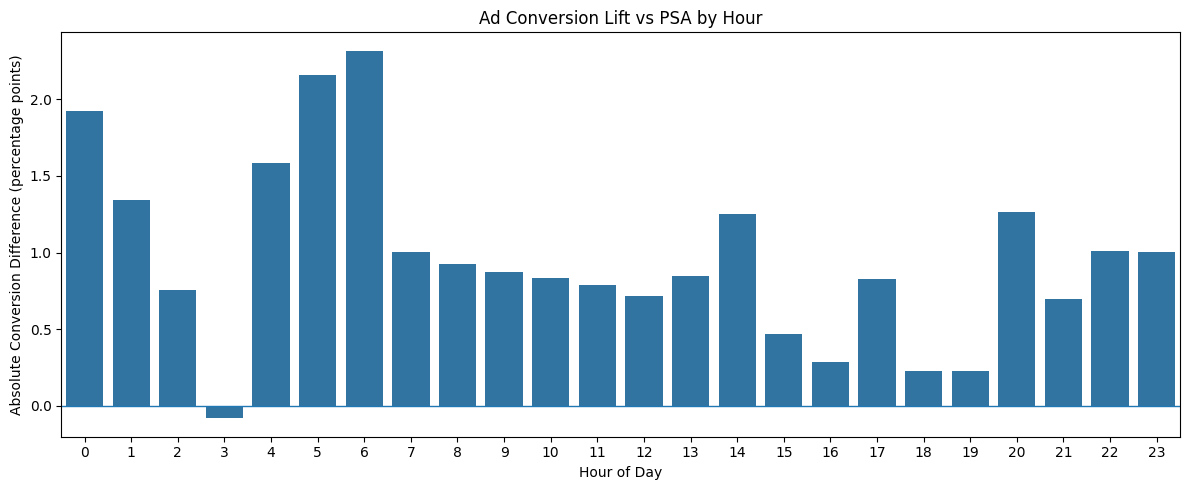

In [11]:
hour_chart = hour_results.copy()

hour_chart["absolute_difference_pct"] = (
    hour_chart["absolute_difference"] * 100
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=hour_chart,
    x="hour",
    y="absolute_difference_pct"
)

plt.axhline(0, linewidth=1)

plt.title("Ad Conversion Lift vs PSA by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Absolute Conversion Difference (percentage points)")

plt.tight_layout()
plt.show()

In [12]:
hour_evidence = hour_results.copy()

hour_evidence["absolute_difference_pp"] = (
    hour_evidence["absolute_difference"] * 100
)

hour_evidence["ci_lower_pp"] = (
    hour_evidence["ci_lower"] * 100
)

hour_evidence["ci_upper_pp"] = (
    hour_evidence["ci_upper"] * 100
)

hour_evidence["relative_lift_pct"] = (
    hour_evidence["relative_lift"] * 100
)

hour_evidence[
    [
        "hour",
        "ad_users",
        "psa_users",
        "ad_conversion_rate",
        "psa_conversion_rate",
        "absolute_difference_pp",
        "ci_lower_pp",
        "ci_upper_pp",
        "p_value_adjusted",
        "significant_after_bh",
        "cohens_h"
    ]
]

,hour,ad_users,psa_users,ad_conversion_rate,psa_conversion_rate,absolute_difference_pp,ci_lower_pp,ci_upper_pp,p_value_adjusted,significant_after_bh,cohens_h
0,0,5309,227,0.019213,0.000000,1.921266,1.552007,2.290525,0.112413,False,0.278115
1,1,4615,187,0.013434,0.000000,1.343445,1.011288,1.675602,0.204252,False,0.232336
2,2,5152,181,0.007570,0.000000,0.756988,0.520307,0.993668,0.340253,False,0.174230
3,3,2590,89,0.010425,0.011236,-0.081124,-2.305627,2.143378,0.941015,False,-0.007839
4,4,694,28,0.015850,0.000000,1.585014,0.655784,2.514245,0.593839,False,0.252465
5,5,742,23,0.021563,0.000000,2.156334,1.111184,3.201484,0.593839,False,0.294755
6,6,1985,83,0.023174,0.000000,2.317380,1.655494,2.979266,0.275567,False,0.305647
7,7,6168,237,0.018482,0.008439,1.004367,-0.207786,2.216520,0.340253,False,0.088760
8,8,16968,659,0.019861,0.010622,0.923876,0.113501,1.734251,0.196454,False,0.076305
9,9,29802,1202,0.019529,0.010815,0.871358,0.265882,1.476835,0.112413,False,0.072039


In [13]:
significant_hours = hour_results[
    hour_results["significant_after_bh"]
].copy()

significant_hours["absolute_difference_pp"] = (
    significant_hours["absolute_difference"] * 100
)

significant_hours["ci_lower_pp"] = (
    significant_hours["ci_lower"] * 100
)

significant_hours["ci_upper_pp"] = (
    significant_hours["ci_upper"] * 100
)

significant_hours[
    [
        "hour",
        "ad_users",
        "psa_users",
        "absolute_difference_pp",
        "ci_lower_pp",
        "ci_upper_pp",
        "p_value_adjusted",
        "cohens_h"
    ]
]

,hour,ad_users,psa_users,absolute_difference_pp,ci_lower_pp,ci_upper_pp,p_value_adjusted,cohens_h
14,14,43779,1869,1.252398,0.661647,1.843149,0.03179,0.085645


## Segment Analysis Conclusion

### Day-of-Week Findings

The Ad treatment showed a positive conversion-rate difference relative to PSA across all seven days.

After Benjamini–Hochberg correction for multiple comparisons, statistically significant positive differences remained on:

- Monday: +1.07 percentage points
- Tuesday: +1.60 percentage points
- Wednesday: +0.96 percentage points
- Friday: +0.62 percentage points
- Saturday: +0.73 percentage points

Thursday (+0.14 pp) and Sunday (+0.40 pp) did not remain statistically significant after correction.

Although Tuesday showed the largest observed lift, segment-level results should not be interpreted as proof that the treatment is causally stronger on Tuesday. Day-of-week is an exploratory behavioral segmentation variable in this dataset.

### Hour-of-Day Findings

Twenty-four hourly treatment comparisons were evaluated and Benjamini–Hochberg correction was applied.

Only 14:00 remained statistically significant after correction:

- Ad − PSA difference: +1.25 percentage points
- 95% CI: +0.66 to +1.84 percentage points
- BH-adjusted p-value: 0.03179
- Cohen's h: 0.0856 (small effect)

Other hourly differences did not provide sufficient evidence after correction.

Several early-hour segments had very small PSA sample sizes and zero conversions. Their apparent relative lifts are therefore unstable and should not be used for targeting decisions.

### Overall Segment Interpretation

The overall experiment shows a clear positive conversion difference for the Ad group, while segment analysis indicates that the magnitude of the observed difference varies across days and hours.

However, most segment-specific effects are small, and only a limited number remain statistically significant after controlling the false discovery rate.

Therefore, segment analysis should be treated as exploratory evidence rather than as a basis for narrowly targeting specific days or hours.

The primary business decision should rely on the overall experiment result, experiment-validity checks, effect size, confidence interval, and business economics.

### Methodological caveat

Hourly z-test results for very low-volume segments should be interpreted cautiously because normal-approximation assumptions may be weak. These low-volume segments were not used for the business decision; hourly findings are exploratory and should not be ranked solely by relative lift.